# Genetic Algorithm untuk Penjadwalan Kuliah
## Fokus Pembelajaran: Elitism, Constraint, dan Evolusi Solusi

Notebook ini dirancang sebagai eksperimen pada skema generasi, crossover, mutasi, dan penggunaan *elitism*. Studi kasus yang digunakan adalah **optimasi penjadwalan kuliah** menggunakan **Genetic Algorithm (GA)**.

### Temuan Eksperimen





> Muhammad Fikri
> 24060124130069


## 1. Studi Kasus

Program Studi Informatika ingin menyusun jadwal kuliah dengan memperhatikan:

### Hard Constraint
Pelanggaran hard constraint dianggap serius.

- Seorang dosen tidak boleh mengajar dua mata kuliah pada waktu yang sama.
- Satu ruang tidak boleh digunakan dua mata kuliah pada waktu yang sama.
- Kapasitas ruang harus cukup.
- Mata kuliah pada semester yang sama tidak boleh berlangsung pada waktu yang sama.

### Soft Constraint
Soft constraint boleh dilanggar, tetapi mengurangi kualitas jadwal.

- Sebisa mungkin jadwal mengikuti slot waktu yang disukai dosen.

### Bobot penalti

| Pelanggaran | Penalti |
|---|---:|
| Bentrok dosen | 25 |
| Bentrok ruang | 25 |
| Kapasitas ruang kurang | 20 |
| Bentrok semester | 20 |
| Tidak sesuai preferensi dosen | 5 |

Fitness dihitung dengan:

$
Fitness = \max(0,\ 100 - TotalPenalty)
$

Semakin tinggi fitness, semakin baik jadwal.

In [31]:
import random
import copy
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Environment siap.")

# Konfigurasi
POP_SIZE = 30         # Ukuran Populasi
MUTATION_RATE = 0.1   # Ukuran persentase awal mutasi
CROSSOVER_POINTS = 2  # Crossover 2 Titik
PATIENCE = 10         # Early stopping patience
BASE_ELITE_SIZE = 2   # Base elite size untuk dynamic elitism
ELITE_SIZE = 2

Environment siap.


In [32]:
# Data mata kuliah
courses = [
    {"name": "Algoritma",       "lecturer": "Andi",  "students": 35, "semester": 3},
    {"name": "Basis Data",      "lecturer": "Budi",  "students": 40, "semester": 3},
    {"name": "RPL",             "lecturer": "Andi",  "students": 30, "semester": 5},
    {"name": "Kecerdasan AI",   "lecturer": "Citra", "students": 45, "semester": 5},
    {"name": "Jaringan",        "lecturer": "Budi",  "students": 25, "semester": 5},
    {"name": "Data Mining",     "lecturer": "Citra", "students": 38, "semester": 5},
    {"name": "Sistem Operasi",  "lecturer": "Deni",  "students": 42, "semester": 3},
    {"name": "IoT",             "lecturer": "Deni",  "students": 28, "semester": 7},
]

rooms = [
    {"name": "R101", "capacity": 30},
    {"name": "R102", "capacity": 40},
    {"name": "R103", "capacity": 50},
]

timeslots = [
    "Senin 08.00",
    "Senin 10.00",
    "Selasa 08.00",
    "Selasa 10.00",
    "Rabu 08.00",
    "Rabu 10.00",
]

# Preferensi dosen hanya untuk contoh soft constraint
lecturer_preferences = {
    "Andi":  {0, 1, 2},
    "Budi":  {1, 2, 3},
    "Citra": {2, 3, 4},
    "Deni":  {0, 4, 5},
}

formatted_lecturer_preferences = {}
for lecturer, slots_ids in lecturer_preferences.items():
    preferred_times = [timeslots[slot_id] for slot_id in sorted(list(slots_ids))]
    formatted_lecturer_preferences[lecturer] = ", ".join(preferred_times)

df_courses = pd.DataFrame(courses)
df_rooms = pd.DataFrame(rooms)

print("DATA MATA KULIAH")
display(df_courses)

print("\nDATA RUANG")
display(df_rooms)

print("\nSLOT WAKTU")
display(pd.DataFrame({"slot_id": range(len(timeslots)), "waktu": timeslots}))

print("\nPREFERENSI DOSEN")
df_lecturer_preferences = pd.DataFrame.from_dict(
    formatted_lecturer_preferences,
    orient='index',
    columns=['Preferred Timeslots']
)
display(df_lecturer_preferences)

DATA MATA KULIAH


,name,lecturer,students,semester
0,Algoritma,Andi,35,3
1,Basis Data,Budi,40,3
2,RPL,Andi,30,5
3,Kecerdasan AI,Citra,45,5
4,Jaringan,Budi,25,5
5,Data Mining,Citra,38,5
6,Sistem Operasi,Deni,42,3
7,IoT,Deni,28,7



DATA RUANG


,name,capacity
0,R101,30
1,R102,40
2,R103,50



SLOT WAKTU


,slot_id,waktu
0,0,Senin 08.00
1,1,Senin 10.00
2,2,Selasa 08.00
3,3,Selasa 10.00
4,4,Rabu 08.00
5,5,Rabu 10.00



PREFERENSI DOSEN


,Preferred Timeslots
Andi,"Senin 08.00, Senin 10.00, Selasa 08.00"
Budi,"Senin 10.00, Selasa 08.00, Selasa 10.00"
Citra,"Selasa 08.00, Selasa 10.00, Rabu 08.00"
Deni,"Senin 08.00, Rabu 08.00, Rabu 10.00"


## 2. Representasi Kromosom

Satu **individu** mewakili satu jadwal lengkap.

Satu **gene** menyimpan:

$
Gene_i = (Timeslot_i,\ Room_i)
$

Contoh:

```text
[(0,1), (2,2), (1,0), ...]
```

Artinya mata kuliah pertama ditempatkan pada slot 0 di ruang 1, mata kuliah kedua pada slot 2 di ruang 2, dan seterusnya.

Dengan demikian:

```text
Chromosome = [G1][G2][G3][G4][G5][G6][G7][G8]
                 satu jadwal lengkap
```

In [33]:
def create_individual(rng=random):
    return [
        [rng.randrange(len(timeslots)), rng.randrange(len(rooms))]
        for _ in courses
    ]

sample_individual = create_individual()
sample_individual

[[5, 0], [0, 2], [2, 0], [1, 0], [5, 0], [5, 2], [4, 0], [4, 1]]

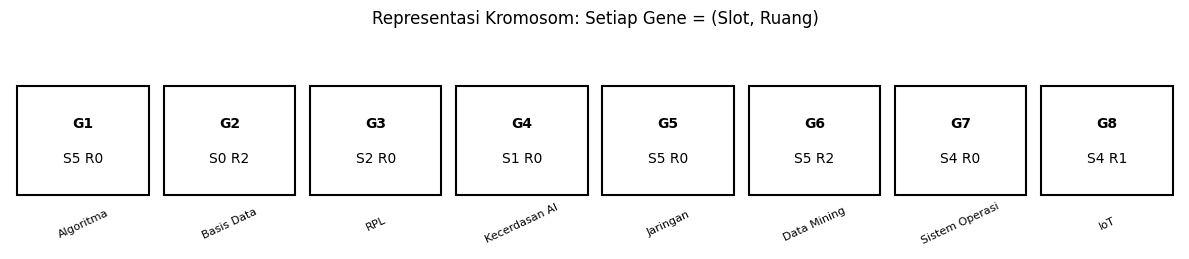

In [34]:
# Visualisasi kromosom
fig, ax = plt.subplots(figsize=(12, 2.7))
ax.set_xlim(0, len(courses))
ax.set_ylim(0, 1)
ax.axis("off")

for i, (course, gene) in enumerate(zip(courses, sample_individual)):
    rect = plt.Rectangle((i + 0.05, 0.25), 0.9, 0.5, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(i + 0.5, 0.58, f"G{i+1}", ha="center", va="center", fontweight="bold")
    ax.text(i + 0.5, 0.42, f"S{gene[0]} R{gene[1]}", ha="center", va="center")
    ax.text(i + 0.5, 0.12, course["name"], ha="center", va="center", rotation=25, fontsize=8)

ax.set_title("Representasi Kromosom: Setiap Gene = (Slot, Ruang)")
plt.tight_layout()
plt.show()

## 3. Fitness Function dan Penalty

Fitness berfungsi untuk memberi nilai pada setiap jadwal.

Kita tidak hanya bertanya:

> "Apakah jadwal ini valid?"

Tetapi:

> "Seberapa baik jadwal ini dibandingkan jadwal lain?"

Karena itu setiap konflik diberi penalti. GA kemudian berusaha **mengurangi penalti dari generasi ke generasi**.

In [35]:
PENALTIES = {
    "lecturer_conflict": 25,
    "room_conflict": 25,
    "capacity": 20,
    "semester_conflict": 20,
    "preference": 5,
}

def evaluate(individual):
    penalty = 0
    violations = []
    breakdown = Counter()

    # Kapasitas dan preferensi
    for i, course in enumerate(courses):
        slot_i, room_i = individual[i]

        if rooms[room_i]["capacity"] < course["students"]:
            penalty += PENALTIES["capacity"]
            breakdown["Kapasitas ruang"] += PENALTIES["capacity"]
            violations.append(
                f"Kapasitas: {course['name']} ({course['students']} mhs) "
                f"tidak muat di {rooms[room_i]['name']} ({rooms[room_i]['capacity']})"
            )

        if slot_i not in lecturer_preferences[course["lecturer"]]:
            penalty += PENALTIES["preference"]
            breakdown["Preferensi dosen"] += PENALTIES["preference"]
            violations.append(
                f"Preferensi: {course['lecturer']} kurang menyukai slot {timeslots[slot_i]} "
                f"untuk {course['name']}"
            )

    # Konflik pasangan mata kuliah
    for i in range(len(courses)):
        slot_i, room_i = individual[i]

        for j in range(i + 1, len(courses)):
            slot_j, room_j = individual[j]

            if slot_i != slot_j:
                continue

            if courses[i]["lecturer"] == courses[j]["lecturer"]:
                penalty += PENALTIES["lecturer_conflict"]
                breakdown["Bentrok dosen"] += PENALTIES["lecturer_conflict"]
                violations.append(
                    f"Dosen: {courses[i]['lecturer']} mengajar {courses[i]['name']} dan "
                    f"{courses[j]['name']} pada {timeslots[slot_i]}"
                )

            if room_i == room_j:
                penalty += PENALTIES["room_conflict"]
                breakdown["Bentrok ruang"] += PENALTIES["room_conflict"]
                violations.append(
                    f"Ruang: {rooms[room_i]['name']} dipakai {courses[i]['name']} dan "
                    f"{courses[j]['name']} pada {timeslots[slot_i]}"
                )

            if courses[i]["semester"] == courses[j]["semester"]:
                penalty += PENALTIES["semester_conflict"]
                breakdown["Bentrok semester"] += PENALTIES["semester_conflict"]
                violations.append(
                    f"Semester: semester {courses[i]['semester']} memiliki {courses[i]['name']} "
                    f"dan {courses[j]['name']} pada {timeslots[slot_i]}"
                )

    fitness_value = max(0, 100 - penalty)

    return {
        "fitness": fitness_value,
        "penalty": penalty,
        "violations": violations,
        "breakdown": breakdown,
    }

sample_eval = evaluate(sample_individual)
sample_eval

{'fitness': 0,
 'penalty': 155,
 'violations': ['Kapasitas: Algoritma (35 mhs) tidak muat di R101 (30)',
  'Preferensi: Andi kurang menyukai slot Rabu 10.00 untuk Algoritma',
  'Preferensi: Budi kurang menyukai slot Senin 08.00 untuk Basis Data',
  'Kapasitas: Kecerdasan AI (45 mhs) tidak muat di R101 (30)',
  'Preferensi: Citra kurang menyukai slot Senin 10.00 untuk Kecerdasan AI',
  'Preferensi: Budi kurang menyukai slot Rabu 10.00 untuk Jaringan',
  'Preferensi: Citra kurang menyukai slot Rabu 10.00 untuk Data Mining',
  'Kapasitas: Sistem Operasi (42 mhs) tidak muat di R101 (30)',
  'Ruang: R101 dipakai Algoritma dan Jaringan pada Rabu 10.00',
  'Semester: semester 5 memiliki Jaringan dan Data Mining pada Rabu 10.00',
  'Dosen: Deni mengajar Sistem Operasi dan IoT pada Rabu 08.00'],
 'breakdown': Counter({'Kapasitas ruang': 60,
          'Preferensi dosen': 25,
          'Bentrok ruang': 25,
          'Bentrok semester': 20,
          'Bentrok dosen': 25})}

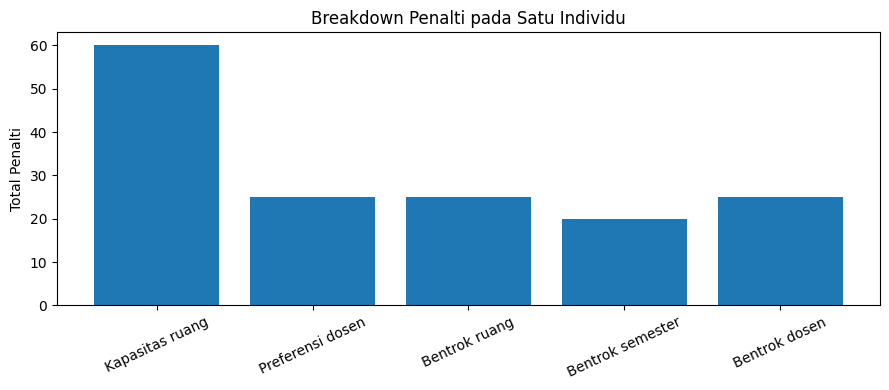

In [36]:
# Visualisasi breakdown penalti individu contoh
breakdown = sample_eval["breakdown"]

if breakdown:
    labels = list(breakdown.keys())
    values = list(breakdown.values())

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(labels, values)
    ax.set_title("Breakdown Penalti pada Satu Individu")
    ax.set_ylabel("Total Penalti")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()
else:
    print("Individu contoh kebetulan tidak memiliki penalti.")

## 4. Population

GA tidak bekerja hanya dengan satu solusi.

GA bekerja dengan sekumpulan solusi yang disebut **population**.

Misalnya:

```text
Population
├── Individu 1 → Fitness 40
├── Individu 2 → Fitness 65
├── Individu 3 → Fitness 80
├── Individu 4 → Fitness 55
└── ...
```

Dari populasi ini, individu yang lebih baik mempunyai peluang lebih besar untuk mewariskan karakteristiknya ke generasi berikutnya.

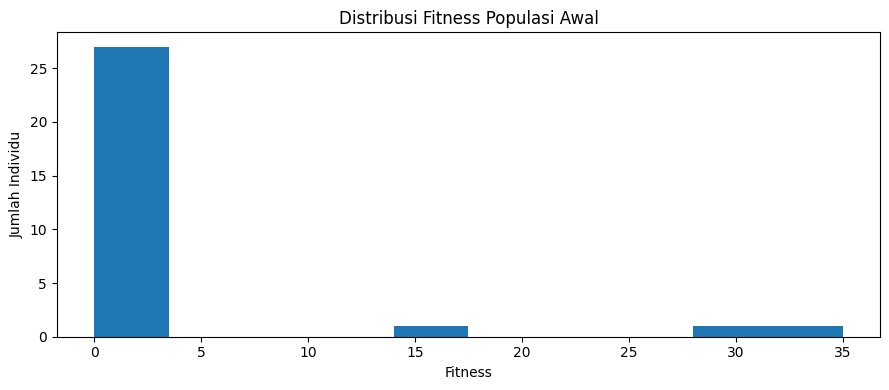

Best fitness awal : 35
Average fitness   : 2.67


In [37]:
# Inisialisasi populasi awal setelah semua fungsi pembentuk kromosom didefinisikan
initial_population = [create_individual() for _ in range(POP_SIZE)]
initial_fitness = [evaluate(ind)["fitness"] for ind in initial_population]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(initial_fitness, bins=10)
ax.set_title("Distribusi Fitness Populasi Awal")
ax.set_xlabel("Fitness")
ax.set_ylabel("Jumlah Individu")
plt.tight_layout()
plt.show()

print("Best fitness awal :", max(initial_fitness))
print("Average fitness   :", round(np.mean(initial_fitness), 2))

## 5. Selection: Tournament Selection

Pada contoh ini digunakan **Tournament Selection**.

Dua individu dipilih secara acak:

```text
Candidate A → Fitness 65
Candidate B → Fitness 85
                  ↓
             B menjadi parent
```

Selection meningkatkan kemungkinan individu bagus menghasilkan keturunan, tetapi masih mempertahankan unsur stokastik.

In [38]:
def selection(population, rng=random):
    a = rng.choice(population)
    b = rng.choice(population)

    if evaluate(a)["fitness"] >= evaluate(b)["fitness"]:
        return copy.deepcopy(a)
    return copy.deepcopy(b)

## 6. Crossover

Crossover menggabungkan bagian dari dua parent.

Contoh:

```text
Parent A : [A][B][C][D] | [E][F][G][H]
Parent B : [a][b][c][d] | [e][f][g][h]

                         ↓ crossover

Child    : [A][B][C][D] | [e][f][g][h]
```

Tujuannya adalah menggabungkan bagian jadwal yang baik dari dua solusi berbeda.

In [39]:
def crossover(parent1, parent2, rng=random):
    if CROSSOVER_POINTS == 2:
        # Crossover 2 Titik
        size = len(courses)
        point1 = rng.randint(1, size - 2)
        point2 = rng.randint(point1 + 1, size - 1)

        child = parent1[:point1] + parent2[point1:point2] + parent1[point2:]
        return copy.deepcopy(child), (point1, point2)
    else:
        # Default 1 Titik
        point = rng.randint(1, len(courses) - 1)
        child = parent1[:point] + parent2[point:]
        return copy.deepcopy(child), point

parent_a = selection(initial_population)
parent_b = selection(initial_population)
child_demo, crossover_point = crossover(parent_a, parent_b)

print("Crossover point:", crossover_point)

Crossover point: (6, 7)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

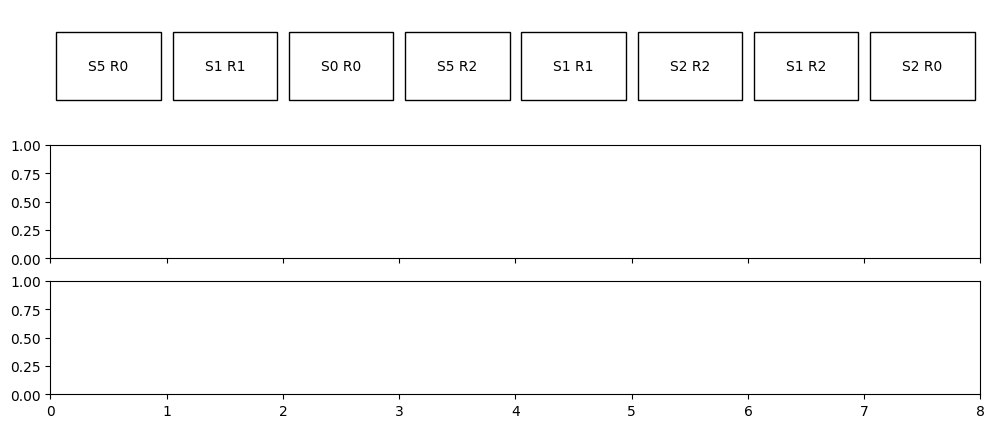

In [40]:
# Visualisasi crossover
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

rows = [
    ("Parent A", parent_a),
    ("Parent B", parent_b),
    ("Child", child_demo),
]

for ax, (title, individual) in zip(axes, rows):
    ax.set_xlim(0, len(courses))
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_ylabel(title, rotation=0, labelpad=45, va="center")

    for i, gene in enumerate(individual):
        rect = plt.Rectangle((i + 0.05, 0.2), 0.9, 0.6, fill=False)
        ax.add_patch(rect)
        ax.text(i + 0.5, 0.5, f"S{gene[0]} R{gene[1]}", ha="center", va="center")

    ax.axvline(crossover_point, linestyle="--")

axes[-1].set_xticks(np.arange(len(courses)) + 0.5)
axes[-1].set_xticklabels([c["name"] for c in courses], rotation=25, ha="right")
fig.suptitle("Visualisasi One-Point Crossover")
plt.tight_layout()
plt.show()

## 7. Mutation

Mutation mengubah sebagian kecil gene secara acak.

Contoh:

```text
Sebelum mutation:
AI → Selasa 08.00 → R102

Sesudah mutation:
AI → Rabu 08.00 → R103
```

Mutation penting untuk **exploration**, yaitu membuka kemungkinan solusi baru yang belum ada di population.

In [ ]:
def mutation(individual, mutation_rate=MUTATION_RATE, rng=random):
    child = copy.deepcopy(individual)
    original_fitness = evaluate(child)["fitness"]
    mutated_positions = []

    # Lakukan mutasi sementara
    temp_child = copy.deepcopy(child)
    for i, gene in enumerate(temp_child):
        if rng.random() < mutation_rate:
            temp_child[i] = [
                rng.randrange(len(timeslots)),
                rng.randrange(len(rooms))
            ]
            mutated_positions.append(i)

    # Hanya ambil hasil mutasi jika fitnessnya lebih baik/setara
    if evaluate(temp_child)["fitness"] > original_fitness:
        return temp_child, mutated_positions
    else:
        # Mutasi jelek langsung dibuang, kembalikan kromosom asli
        return child, []

mutated_child, mutated_positions = mutation(child_demo, mutation_rate=0.35)

print("Gene yang berhasil mengalami mutation (lebih baik):", mutated_positions)

In [ ]:
# Visualisasi mutation
fig, axes = plt.subplots(2, 1, figsize=(12, 3.8), sharex=True)

for ax, title, individual in [
    (axes[0], "Sebelum Mutation", child_demo),
    (axes[1], "Sesudah Mutation", mutated_child),
]:
    ax.set_xlim(0, len(courses))
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_ylabel(title, rotation=0, labelpad=60, va="center")

    for i, gene in enumerate(individual):
        linewidth = 3 if i in mutated_positions and title == "Sesudah Mutation" else 1
        rect = plt.Rectangle((i + 0.05, 0.2), 0.9, 0.6, fill=False, linewidth=linewidth)
        ax.add_patch(rect)
        ax.text(i + 0.5, 0.5, f"S{gene[0]} R{gene[1]}", ha="center", va="center")

axes[-1].set_xticks(np.arange(len(courses)) + 0.5)
axes[-1].set_xticklabels([c["name"] for c in courses], rotation=25, ha="right")
fig.suptitle("Visualisasi Mutation: Kotak Tebal Menandai Gene yang Berubah")
plt.tight_layout()
plt.show()

# 8. Fokus Utama: Elitism

## Apa itu Elitism?

**Elitism** adalah strategi untuk membawa beberapa individu terbaik dari generasi saat ini **langsung** ke generasi berikutnya.

Individu elite:

- tidak melalui crossover,
- tidak melalui mutation,
- tidak diubah,
- dipertahankan persis seperti sebelumnya.

Contoh jika:

```text
Population size = 10
Elite size      = 2
```

maka generasi baru berisi:

```text
New Population
├── Elite 1      ← langsung dipertahankan
├── Elite 2      ← langsung dipertahankan
├── Child 1      ← selection + crossover + mutation
├── Child 2
├── Child 3
├── Child 4
├── Child 5
├── Child 6
├── Child 7
└── Child 8
```

Secara sederhana:

\[
10 = 2\ Elite + 8\ Offspring
\]

## Mengapa Elitism penting?

Bayangkan generasi ke-7 sudah memiliki jadwal dengan:

\[
Fitness = 95
\]

Tanpa elitism, jadwal ini dapat hilang karena proses crossover, mutation, dan replacement.

Dengan elitism, jadwal tersebut disalin langsung ke generasi berikutnya.

Karena itu:

> **Best fitness pada GA dengan elitism secara teoritis tidak boleh memburuk dari satu generasi ke generasi berikutnya, selama elite benar-benar disalin tanpa perubahan.**

Namun elite yang terlalu banyak juga dapat mengurangi diversity dan menyebabkan **premature convergence**.

In [ ]:
ELITE_SIZE = 10

def get_elites(population, elite_size=ELITE_SIZE):
    sorted_population = sorted(
        population,
        key=lambda ind: evaluate(ind)["fitness"],
        reverse=True
    )
    return copy.deepcopy(sorted_population[:elite_size])

# Contoh elite pada populasi awal
ranked = sorted(initial_population, key=lambda x: evaluate(x)["fitness"], reverse=True)
rank_table = []

for i, ind in enumerate(ranked[:10]):
    rank_table.append({
        "Rank": i + 1,
        "Fitness": evaluate(ind)["fitness"],
        "Status": "ELITE" if i < ELITE_SIZE else "Non-Elite"
    })

display(pd.DataFrame(rank_table))

In [ ]:
# Visualisasi ranking dan elite
top10 = pd.DataFrame(rank_table)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(top10["Rank"].astype(str), top10["Fitness"])
ax.set_title("Ranking Individu: Dua Individu Terbaik Menjadi Elite")
ax.set_xlabel("Rank")
ax.set_ylabel("Fitness")

for i, bar in enumerate(bars):
    if i < ELITE_SIZE:
        bar.set_hatch("//")

plt.tight_layout()
plt.show()

print("Bar dengan pola arsiran = ELITE")

## 9. Fungsi Genetic Algorithm Lengkap

Parameter utama yang akan digunakan:

- `population_size`
- `generations`
- `mutation_rate`
- `elite_size`

Perhatikan bahwa `elite_size` adalah parameter yang sengaja dibuat eksplisit agar kita dapat melakukan eksperimen **dengan dan tanpa elitism**.

In [ ]:
def individual_key(individual):
    return tuple((gene[0], gene[1]) for gene in individual)

def run_ga(
    initial_population,
    generations=999999,
    mutation_rate=0.12,
    base_elite_size=BASE_ELITE_SIZE,
    seed=42,
    patience=PATIENCE,
    stop_at_optimum=True
):
    rng = random.Random(seed)
    population = copy.deepcopy(initial_population)

    history = {
        "generation": [],
        "best_fitness": [],
        "avg_fitness": [],
        "best_penalty": [],
        "diversity": [],
        "elite_size_history": []
    }

    best_ever = None
    best_ever_fitness = -1
    no_improvement_counter = 0
    current_elite_size = base_elite_size

    for generation in range(generations + 1):
        scored = [(ind, evaluate(ind)) for ind in population]
        scored.sort(key=lambda x: x[1]["fitness"], reverse=True)

        current_best = scored[0][0]
        current_eval = scored[0][1]
        fitness_values = [s["fitness"] for _, s in scored]

        # Tracking Best Solution
        if current_eval["fitness"] > best_ever_fitness:
            best_ever = copy.deepcopy(current_best)
            best_ever_fitness = current_eval["fitness"]
            no_improvement_counter = 0  # Reset patience tracker
        else:
            no_improvement_counter += 1

        # ==========================
        # DYNAMIC ELITISM SCHEDULER
        # ==========================
        # Jika generasi mulai stagnan, kita tingkatkan elite_size secara berkala
        # untuk memperkuat eksploitasi solusi terbaik saat ini (eksploitasi tinggi)
        if no_improvement_counter > 0 and no_improvement_counter % 2 == 0:
            current_elite_size = min(POP_SIZE // 2, current_elite_size + 1)
        elif no_improvement_counter == 0:
            current_elite_size = base_elite_size

        history["generation"].append(generation)
        history["best_fitness"].append(current_eval["fitness"])
        history["avg_fitness"].append(float(np.mean(fitness_values)))
        history["best_penalty"].append(current_eval["penalty"])
        history["diversity"].append(len({individual_key(ind) for ind in population}))
        history["elite_size_history"].append(current_elite_size)

        # Cek kondisi stop
        if stop_at_optimum and current_eval["fitness"] == 100:
            print(f"[Konvergen] Solusi optimal ditemukan pada generasi ke-{generation}!")
            break

        if no_improvement_counter >= patience:
            print(f"[Early Stopping] Berhenti karena tidak ada perkembangan setelah {patience} generasi (Gen: {generation}).")
            break

        if generation == generations:
            break

        # Elitism
        elites = get_elites(population, elite_size=current_elite_size) if current_elite_size > 0 else []
        new_population = copy.deepcopy(elites)

        # Regenerasi sisa populasi
        while len(new_population) < len(population):
            parent1 = selection(population, rng=rng)
            parent2 = selection(population, rng=rng)

            child, _ = crossover(parent1, parent2, rng=rng)
            # Mutasi yang buruk dibuang otomatis di dalam fungsi mutation()
            child, _ = mutation(child, mutation_rate=mutation_rate, rng=rng)

            new_population.append(child)

        population = new_population

    return {
        "best_ever": best_ever,
        "best_ever_eval": evaluate(best_ever),
        "final_population": population,
        "history": pd.DataFrame(history),
    }

In [ ]:
# Eksekusi GA Terupdate
ga_advanced = run_ga(
    initial_population=initial_population,
    generations=1000, # Mensimulasikan limit generasi besar/tak hingga
    mutation_rate=0.12,
    base_elite_size=2,
    seed=42,
    patience=10,
    stop_at_optimum=True
)

hist_advanced = ga_advanced["history"]

# Visualisasi Perkembangan Fitness dan Perubahan Elitism Dinamis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Subplot 1: Fitness
ax1.plot(hist_advanced["generation"], hist_advanced["best_fitness"], marker="o", markersize=3, label="Best fitness")
ax1.plot(hist_advanced["generation"], hist_advanced["avg_fitness"], label="Average fitness")
ax1.set_title("Perkembangan Fitness GA Terupdate (Dengan Dynamic Elitism)")
ax1.set_ylabel("Fitness")
ax1.legend()
ax1.grid(alpha=0.25)

# Subplot 2: Dynamic Elite Size (Scheduler)
ax2.plot(hist_advanced["generation"], hist_advanced["elite_size_history"], color='r', marker='s', markersize=3, label="Elite Size (Dynamic)")
ax2.set_title("Ukuran Elitism Dinamis (Scheduler)")
ax2.set_xlabel("Generation")
ax2.set_ylabel("Elite Size")
ax2.legend()
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("\nBest fitness akhir:", ga_advanced["best_ever_eval"]["fitness"])
print("Total generasi berjalan:", len(hist_advanced) - 1)

## 10. Menjalankan GA dengan Elitism

Kita gunakan:

```text
Population size = 30
Elite size      = 2
Mutation rate   = 12%
Generations     = 40
```

Perhatikan tren:

1. **Best fitness** menunjukkan solusi terbaik tiap generasi.
2. **Average fitness** menunjukkan kualitas populasi secara umum.
3. **Diversity** menunjukkan berapa banyak kromosom unik yang masih terdapat pada populasi.

In [ ]:
# Gunakan populasi awal yang sama agar eksperimen reproducible
ga_elite = run_ga(
    initial_population=initial_population,
    generations=40,
    mutation_rate=0.12,
    base_elite_size=2,
    seed=42
)

hist_elite = ga_elite["history"]

display(hist_elite.head(10))

print("\nBest fitness keseluruhan:", ga_elite["best_ever_eval"]["fitness"])
print("Best penalty keseluruhan:", ga_elite["best_ever_eval"]["penalty"])

In [ ]:
# Visualisasi fitness
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(hist_elite["generation"], hist_elite["best_fitness"], marker="o", markersize=3, label="Best fitness")
ax.plot(hist_elite["generation"], hist_elite["avg_fitness"], label="Average fitness")
ax.set_title("Perkembangan Fitness GA dengan Elitism")
ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Visualisasi diversity
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_elite["generation"], hist_elite["diversity"], marker="o", markersize=3)
ax.set_title("Population Diversity selama Evolusi")
ax.set_xlabel("Generation")
ax.set_ylabel("Jumlah Kromosom Unik")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 11. Eksperimen Penting: Elitism vs Tanpa Elitism

Inilah eksperimen utama untuk pembelajaran.

Kita menjalankan dua GA menggunakan:

- populasi awal yang sama,
- jumlah generasi yang sama,
- mutation rate yang sama.

Perbedaannya hanya:

```text
Eksperimen A : elite_size = 0
Eksperimen B : elite_size = 2
```

Pertanyaan untuk mahasiswa sebelum grafik ditampilkan:

> **Menurut Anda, apa yang akan terjadi pada best fitness jika elitism dimatikan?**

Hipotesis yang ingin diuji:

- Dengan elitism, solusi terbaik tidak hilang.
- Tanpa elitism, best fitness suatu generasi dapat lebih rendah daripada generasi sebelumnya.

In [ ]:
ga_no_elite = run_ga(
    initial_population=initial_population,
    generations=40,
    mutation_rate=0.12,
    base_elite_size=0,
    seed=42
)

hist_no_elite = ga_no_elite["history"]

comparison = pd.DataFrame({
    "Generation": hist_elite["generation"],
    "Dengan Elitism": hist_elite["best_fitness"],
    "Tanpa Elitism": hist_no_elite["best_fitness"],
})

display(comparison.head(15))

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    hist_elite["generation"],
    hist_elite["best_fitness"],
    marker="o",
    markersize=3,
    label="Dengan elitism (elite=2)"
)
ax.plot(
    hist_no_elite["generation"],
    hist_no_elite["best_fitness"],
    marker="o",
    markersize=3,
    label="Tanpa elitism (elite=0)"
)

ax.set_title("Perbandingan Best Fitness: Elitism vs Tanpa Elitism")
ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Deteksi apakah best fitness pernah turun
def count_fitness_drops(history):
    values = history["best_fitness"].to_numpy()
    drops = np.sum(np.diff(values) < 0)
    return int(drops)

summary_compare = pd.DataFrame([
    {
        "Eksperimen": "Dengan Elitism",
        "Best Fitness Akhir": hist_elite["best_fitness"].iloc[-1],
        "Best Fitness Tertinggi": hist_elite["best_fitness"].max(),
        "Jumlah Penurunan Best Fitness": count_fitness_drops(hist_elite),
        "Diversity Akhir": hist_elite["diversity"].iloc[-1],
    },
    {
        "Eksperimen": "Tanpa Elitism",
        "Best Fitness Akhir": hist_no_elite["best_fitness"].iloc[-1],
        "Best Fitness Tertinggi": hist_no_elite["best_fitness"].max(),
        "Jumlah Penurunan Best Fitness": count_fitness_drops(hist_no_elite),
        "Diversity Akhir": hist_no_elite["diversity"].iloc[-1],
    }
])

display(summary_compare)

### Interpretasi Eksperimen

Jika hasil menunjukkan `Jumlah Penurunan Best Fitness = 0` pada GA dengan elitism, hal tersebut sesuai dengan mekanisme elitism:

\[
Elite_t \rightarrow Population_{t+1}
\]

Solusi terbaik disalin langsung ke generasi berikutnya.

Tanpa elitism, solusi terbaik dapat hilang ketika seluruh populasi diganti oleh offspring.

### Tetapi apakah elitism selalu semakin baik jika jumlah elite diperbesar?

Tidak selalu.

Elite yang terlalu banyak dapat menyebabkan:

- population diversity turun,
- individu menjadi terlalu seragam,
- eksplorasi berkurang,
- risiko **premature convergence** meningkat.

Karena itu GA membutuhkan keseimbangan:

```text
Exploration                    Exploitation
Mutation                       Selection
Crossover                      ELITISM
     \\                           /
      \\                         /
       ------ Genetic Algorithm
```

# 12. Eksperimen Elite Size

Sekarang bandingkan:

```text
elite_size = 0
elite_size = 1
elite_size = 2
elite_size = 5
elite_size = 10
```

Tujuannya bukan mencari angka elite terbaik secara universal, tetapi menunjukkan bahwa **elitism adalah trade-off** antara mempertahankan solusi bagus dan menjaga diversity.

In [ ]:
elite_sizes = [0, 1, 2, 5, 10]
elite_runs = {}

for elite_size in elite_sizes:
    elite_runs[elite_size] = run_ga(
        initial_population=initial_population,
        generations=40,
        mutation_rate=0.12,
        base_elite_size=elite_size,
        seed=42
    )

fig, ax = plt.subplots(figsize=(11, 5))
for elite_size in elite_sizes:
    h = elite_runs[elite_size]["history"]
    ax.plot(h["generation"], h["best_fitness"], label=f"elite={elite_size}")

ax.set_title("Pengaruh Elite Size terhadap Best Fitness")
ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
for elite_size in elite_sizes:
    h = elite_runs[elite_size]["history"]
    ax.plot(h["generation"], h["diversity"], label=f"elite={elite_size}")

ax.set_title("Pengaruh Elite Size terhadap Population Diversity")
ax.set_xlabel("Generation")
ax.set_ylabel("Jumlah Kromosom Unik")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Pertanyaan Diskusi

1. Mengapa best fitness pada GA dengan elitism seharusnya tidak turun?
2. Mengapa GA tanpa elitism dapat kehilangan solusi terbaik?
3. Mengapa terlalu banyak elite dapat menurunkan diversity?
4. Apa hubungan diversity dengan kemampuan GA mengeksplorasi solusi?
5. Apakah `elite_size = 10` selalu lebih baik daripada `elite_size = 2`?
6. Jika GA mengalami premature convergence, parameter apa saja yang dapat diubah?

# 13. Jadwal Terbaik yang Ditemukan

Selanjutnya kita tampilkan kromosom terbaik sebagai jadwal yang dapat dibaca manusia.

In [ ]:
best_schedule = ga_elite["best_ever"]
best_eval = ga_elite["best_ever_eval"]

def schedule_to_dataframe(individual):
    rows = []
    for course, gene in zip(courses, individual):
        slot, room = gene
        rows.append({
            "Mata Kuliah": course["name"],
            "Dosen": course["lecturer"],
            "Semester": course["semester"],
            "Mahasiswa": course["students"],
            "Waktu": timeslots[slot],
            "Ruang": rooms[room]["name"],
            "Kapasitas": rooms[room]["capacity"],
        })
    return pd.DataFrame(rows).sort_values(["Waktu", "Ruang"]).reset_index(drop=True)

df_best_schedule = schedule_to_dataframe(best_schedule)

print("BEST FITNESS :", best_eval["fitness"])
print("TOTAL PENALTY:", best_eval["penalty"])
display(df_best_schedule)

In [ ]:
# Visualisasi jadwal sebagai matriks slot x ruang
schedule_matrix = [["" for _ in rooms] for _ in timeslots]

for course, gene in zip(courses, best_schedule):
    slot, room = gene
    label = course["name"]
    if schedule_matrix[slot][room]:
        schedule_matrix[slot][room] += "\n" + label
    else:
        schedule_matrix[slot][room] = label

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, len(rooms))
ax.set_ylim(0, len(timeslots))
ax.invert_yaxis()

ax.set_xticks(np.arange(len(rooms)) + 0.5)
ax.set_xticklabels([f"{r['name']}\nCap {r['capacity']}" for r in rooms])

ax.set_yticks(np.arange(len(timeslots)) + 0.5)
ax.set_yticklabels(timeslots)

for i in range(len(timeslots)):
    for j in range(len(rooms)):
        rect = plt.Rectangle((j, i), 1, 1, fill=False)
        ax.add_patch(rect)
        text = schedule_matrix[i][j] if schedule_matrix[i][j] else "-"
        ax.text(j + 0.5, i + 0.5, text, ha="center", va="center", fontsize=9)

ax.set_title("Visualisasi Jadwal Terbaik")
ax.set_xlabel("Ruang")
ax.set_ylabel("Waktu")
plt.tight_layout()
plt.show()

In [ ]:
# Laporan pelanggaran jadwal terbaik
if best_eval["violations"]:
    print("Masih ada pelanggaran:")
    for i, violation in enumerate(best_eval["violations"], 1):
        print(f"{i}. {violation}")
else:
    print("Tidak ada pelanggaran hard/soft constraint pada jadwal terbaik.")

# 14. Visualisasi Penalty dari Generasi ke Generasi

Karena fitness meningkat ketika penalty berkurang, kita juga dapat melihat proses optimasi dari sisi **penalty minimization**.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_elite["generation"], hist_elite["best_penalty"], marker="o", markersize=3)
ax.set_title("Penurunan Penalti Jadwal Terbaik")
ax.set_xlabel("Generation")
ax.set_ylabel("Total Penalty")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 15. Eksperimen Multi-Run

GA bersifat stokastik. Satu kali run belum cukup untuk memahami perilakunya.

Pada eksperimen ini kita menjalankan algoritma beberapa kali dengan seed berbeda untuk membandingkan:

- fitness akhir,
- jumlah penurunan best fitness,
- diversity akhir.

Ini juga memperlihatkan mengapa evaluasi algoritma optimasi sebaiknya tidak hanya berdasarkan satu kali percobaan.

In [ ]:
multi_results = []

for seed in range(10):
    # populasi awal baru untuk tiap seed, tetapi sama untuk pasangan eksperimen
    rng_init = random.Random(seed)
    init_pop = [create_individual(rng=rng_init) for _ in range(POP_SIZE)]

    for label, elite_size in [("Dengan Elitism", 2), ("Tanpa Elitism", 0)]:
        result = run_ga(
            initial_population=init_pop,
            generations=40,
            mutation_rate=0.12,
            base_elite_size=elite_size,
            seed=seed
        )
        h = result["history"]

        multi_results.append({
            "Seed": seed,
            "Metode": label,
            "Best Fitness Akhir": h["best_fitness"].iloc[-1],
            "Best Fitness Tertinggi": h["best_fitness"].max(),
            "Penurunan Best Fitness": count_fitness_drops(h),
            "Diversity Akhir": h["diversity"].iloc[-1],
        })

df_multi = pd.DataFrame(multi_results)
display(df_multi.head(10))

In [ ]:
summary_multi = (
    df_multi
    .groupby("Metode")
    .agg(
        Mean_Final_Fitness=("Best Fitness Akhir", "mean"),
        Std_Final_Fitness=("Best Fitness Akhir", "std"),
        Mean_Drops=("Penurunan Best Fitness", "mean"),
        Mean_Final_Diversity=("Diversity Akhir", "mean")
    )
    .round(2)
)

display(summary_multi)

In [ ]:
# Visualisasi rerata hasil multi-run
plot_df = summary_multi.reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(plot_df["Metode"], plot_df["Mean_Final_Fitness"])
ax.set_title("Rata-rata Fitness Akhir dari 10 Run")
ax.set_ylabel("Mean Final Fitness")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(plot_df["Metode"], plot_df["Mean_Drops"])
ax.set_title("Rata-rata Jumlah Penurunan Best Fitness")
ax.set_ylabel("Jumlah Penurunan")
plt.tight_layout()
plt.show()

# 16. Ringkasan Konsep

## Struktur Genetic Algorithm

```text
Initial Population
        ↓
Fitness Evaluation
        ↓
Ranking
        ↓
┌───────────────────────────┐
│ ELITISM                   │
│ simpan solusi terbaik     │
└───────────────────────────┘
        ↓
Selection
        ↓
Crossover
        ↓
Mutation
        ↓
Elite + Offspring
        ↓
New Population
        ↓
Repeat
```

## Peran setiap operator

| Komponen | Fungsi utama |
|---|---|
| Fitness | Mengukur kualitas solusi |
| Selection | Memilih parent yang relatif baik |
| Crossover | Menggabungkan karakteristik parent |
| Mutation | Menghasilkan variasi baru |
| **Elitism** | **Menjamin solusi terbaik tidak hilang** |

### Kalimat utama untuk mahasiswa

> **Mutation membantu GA mencari kemungkinan baru, sedangkan elitism memastikan GA tidak melupakan solusi terbaik yang sudah ditemukan.**

### Exploration vs Exploitation

- **Exploration**: crossover dan mutation membantu mencari area solusi baru.
- **Exploitation**: selection dan elitism mempertahankan serta memanfaatkan solusi yang sudah baik.

GA yang efektif memerlukan keseimbangan keduanya.

# 17. Aktivitas Kelas

## Aktivitas 1: Menjadi Fitness Evaluator
Buat satu jadwal secara manual. Temukan:

- konflik dosen,
- konflik ruang,
- kekurangan kapasitas,
- konflik semester,
- pelanggaran preferensi dosen.

Hitung fitness jadwal tersebut.

## Aktivitas 2: Prediksi sebelum menjalankan kode
Sebelum menjalankan eksperimen `elite_size = 0` dan `elite_size = 2`, tulis prediksi:

1. Mana yang memiliki best fitness lebih stabil?
2. Pada metode mana best fitness dapat turun?
3. Mana yang mungkin mempertahankan diversity lebih tinggi?

## Aktivitas 3: Eksperimen parameter
Ubah:

```python
MUTATION_RATE = 0.01
MUTATION_RATE = 0.10
MUTATION_RATE = 0.50
```

Kemudian bandingkan hasilnya.

## Aktivitas 4: Eksperimen Elitism
Coba:

```python
ELITE_SIZE = 0
ELITE_SIZE = 1
ELITE_SIZE = 2
ELITE_SIZE = 5
ELITE_SIZE = 10
```

Diskusikan apakah semakin banyak elite selalu menghasilkan pencarian yang lebih baik.

## Aktivitas 5: Pengembangan
Tambahkan constraint baru, misalnya:

- dosen tidak tersedia pada hari tertentu,
- mata kuliah praktikum harus menggunakan laboratorium,
- maksimal tiga kelas per hari untuk satu angkatan,
- tidak boleh ada kelas pada Jumat siang,
- kelas dengan mahasiswa banyak diprioritaskan pada ruang besar.

# 18. Pertanyaan Evaluasi

1. Apa yang dimaksud chromosome pada kasus penjadwalan kuliah?
2. Apa isi satu gene pada implementasi ini?
3. Mengapa konflik dosen diberi penalti lebih tinggi daripada preferensi waktu dosen?
4. Apa fungsi tournament selection?
5. Apa yang terjadi ketika crossover dilakukan?
6. Apa tujuan mutation?
7. Apa perbedaan exploration dan exploitation?
8. Apa fungsi utama elitism?
9. Mengapa best fitness dapat turun jika elitism tidak digunakan?
10. Mengapa elite terlalu banyak dapat menyebabkan premature convergence?
11. Apa perbedaan hard constraint dan soft constraint?
12. Bagaimana Anda mengubah model jika terdapat laboratorium khusus untuk mata kuliah tertentu?

# 19. Kesimpulan

Genetic Algorithm dapat digunakan untuk penjadwalan kuliah karena ruang solusi sangat besar dan terdiri atas banyak kombinasi waktu, ruang, dosen, mata kuliah, dan constraint.

Pada studi kasus ini:

- **chromosome** merepresentasikan satu jadwal lengkap,
- **fitness** mengukur kualitas jadwal,
- **selection** memilih solusi yang berpeluang menjadi parent,
- **crossover** menggabungkan dua jadwal,
- **mutation** membuka kemungkinan konfigurasi baru,
- **elitism** menjaga solusi terbaik agar tidak hilang.

Konsep yang paling penting pada pertemuan ini adalah:

\[
\boxed{\text{Elitism mempertahankan solusi terbaik dari generasi ke generasi}}
\]

Namun elitism bukan berarti semakin banyak elite semakin baik. Jumlah elite perlu diseimbangkan dengan kebutuhan menjaga diversity.